# Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from pyinform.utils import coalesce_series, coalesce
#from pyinform import transfer_entropy
import networkx as nx
from scipy import stats
import sys
print(sys.executable)

c:\Users\taoni\anaconda3\python.exe


### Load data

In [2]:
data = np.genfromtxt("data/allplanes.csv", delimiter=",")

# 1 Data normalization

In [3]:
# Relative change normalization (deltaF/F0)
window_size = 300
n_neurons, n_frames = data.shape

norm_data = np.zeros_like(data, dtype=float)

for i in range(n_neurons):
# for i in range(1):
    neuron = data[i]
    for t in range(n_frames):
        start = max(0, t - window_size)
        if t == 0:
            F0 = neuron[0]
        else:
            window = neuron[start:t]
            if window.size <= 1:
                F0 = neuron[0]
            else:
                median = np.percentile(window, 50)
                lower_half = window[window < median]
                F0 = np.mean(lower_half)
        if F0 == 0:
            F0 = 1e-6
        norm_data[i, t] = (neuron[t] - F0) / F0
    if i % 100 == 0:
        print(f"Neuron {i+1} normalized")

Neuron 1 normalized
Neuron 101 normalized
Neuron 201 normalized
Neuron 301 normalized
Neuron 401 normalized
Neuron 501 normalized
Neuron 601 normalized
Neuron 701 normalized
Neuron 801 normalized
Neuron 901 normalized
Neuron 1001 normalized
Neuron 1101 normalized


In [4]:
# Write norm_data to csv
np.savetxt("norm_allplanes.csv", norm_data, delimiter=",")

# Read norm_data from csv
# norm_allplanes = np.genfromtxt("norm_allplanes.csv", delimiter=",")

# 2 Pearson correlation

### 2.1 Correlation matrix summary (plot and stats)

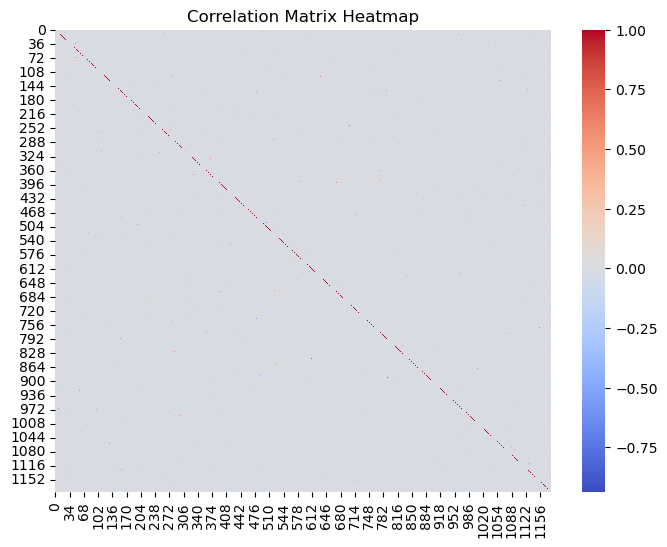

[[ 1.00000000e+00 -1.31250755e-03 -9.41155259e-04 ...  1.27393764e-03
  -3.82423505e-04  1.86799799e-04]
 [-1.31250755e-03  1.00000000e+00  3.88887914e-04 ... -3.02822747e-04
   8.00233500e-05  1.15381202e-03]
 [-9.41155259e-04  3.88887914e-04  1.00000000e+00 ...  3.75231986e-03
  -1.37481780e-03  2.25567453e-04]
 ...
 [ 1.27393764e-03 -3.02822747e-04  3.75231986e-03 ...  1.00000000e+00
   4.39743474e-03  4.08029587e-04]
 [-3.82423505e-04  8.00233500e-05 -1.37481780e-03 ...  4.39743474e-03
   1.00000000e+00 -3.12765742e-04]
 [ 1.86799799e-04  1.15381202e-03  2.25567453e-04 ...  4.08029587e-04
  -3.12765742e-04  1.00000000e+00]]
                R^2
count  6.991530e+05
mean   2.398117e-04
std    6.684266e-03
min    1.890320e-18
25%    1.389283e-07
50%    9.737213e-07
75%    6.904095e-06
max    9.754137e-01


c:\Users\taoni\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


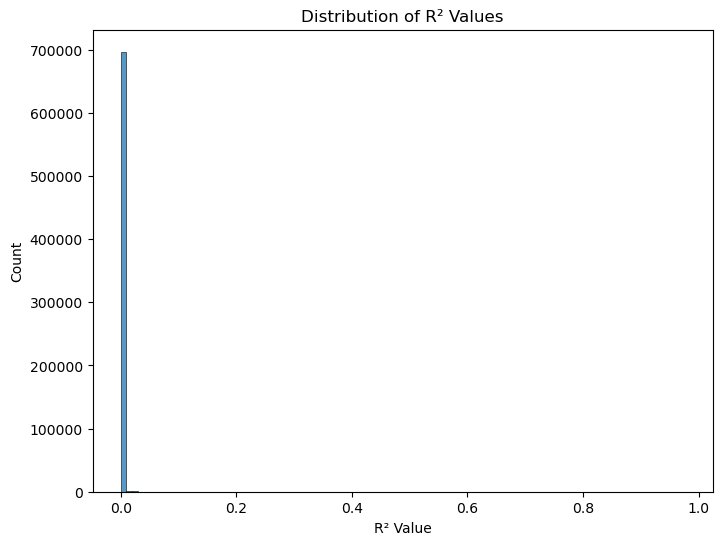

In [5]:
corr_matrix = np.corrcoef(norm_data)

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Summary stats for r^2 values
corr_matrix = np.corrcoef(norm_data)
print(corr_matrix)
r2_vals = np.square(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
df = pd.DataFrame(r2_vals, columns=['R^2'])
print(df.describe())

# Plot histogram of r^2 values
plt.figure(figsize=(8, 6))
sns.histplot(r2_vals, bins=100)
plt.xlabel('R² Value')
plt.title('Distribution of R² Values')
plt.show()

### 2.2 Sensitivity Analysis

In [6]:
def compute_modularity(partition, A):
    """
    Compute modularity Q for a given partition.
    Q = (1/2m) * sum_ij (A_ij - k_i*k_j/2m) * delta(c_i, c_j)
    where k_i is the degree of node i, and delta(c_i, c_j) = 1 if nodes i,j in same community
    """
    n = A.shape[0]

    degrees = A.sum(axis=1)
    m = A.sum() / 2.0  # total edges (double counted in adjacency matrix)
    
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    
    Q /= (2.0 * m)
    return Q

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
            
    penalty = (singleton_count/(len(partition)))+(double_count/(len(partition)*2))
    return (np.mean(conductances) + (1-np.mean(conductances))*penalty) if conductances else np.nan

def communities_to_partition(communities, G_undirected):
    """
    Convert a list of community sets to a partition array.
    Returns: array where partition[i] = community_id for node i
    """
    node_list = list(G_undirected.nodes())  # Use the current graph's node order
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    partition = np.zeros(len(node_list), dtype=int)
    for community_id, community_set in enumerate(communities):
        for node in community_set:
            partition[node_to_idx[node]] = community_id
    return partition

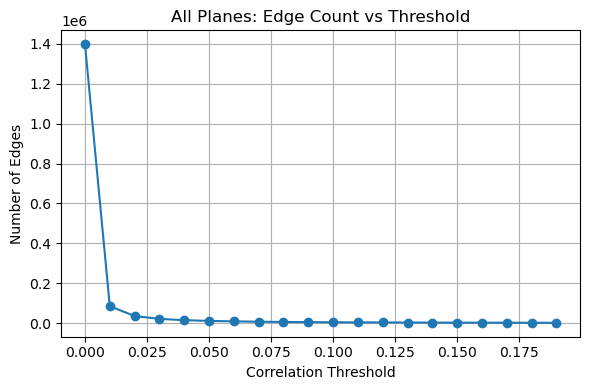

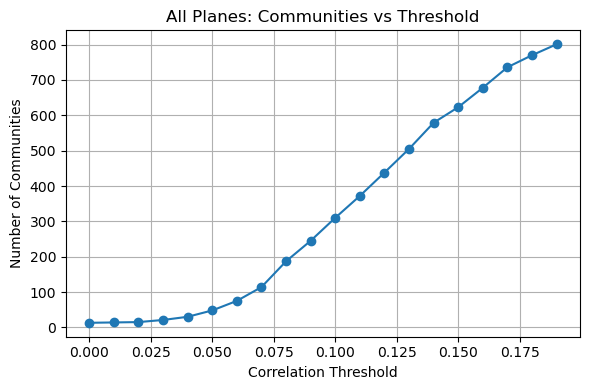

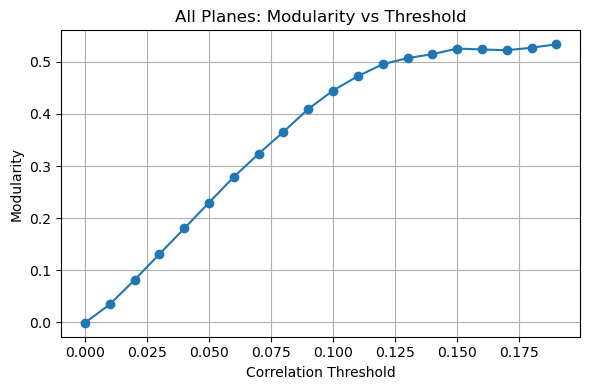

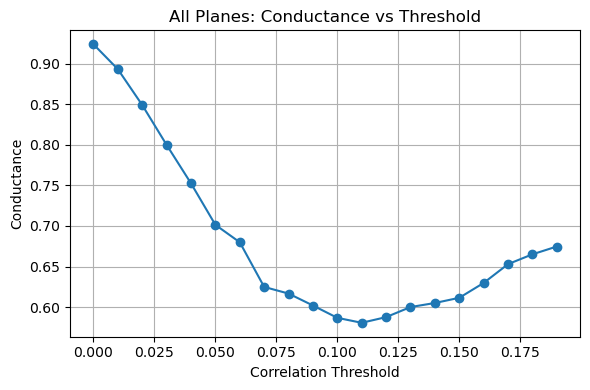

In [7]:
corr_matrix = np.corrcoef(norm_data)

# Remove self-correlations
np.fill_diagonal(corr_matrix, 0)

sensitivity_results = []

# loop through thresholds
for i in range(0,20):
    threshold = 0.01 * i
    
    # make a thresholded copy
    corr_matrix[np.abs(corr_matrix) < threshold] = 0

    # Create undirected weighted graph
    G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)
    # Convert directed graph to undirected
    G_undirected = G.to_undirected()

    # Remove any remaining self-loops
    G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

    # Create unweighted adjacency matrix
    A = nx.adjacency_matrix(G_undirected, weight=None).toarray()
    
    # compute parameters
    communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42))
    partition_louvain = communities_to_partition(communities_louvain, G_undirected)
    mod = compute_modularity(partition_louvain, A)
    cond = compute_conductance(partition_louvain, A)
    k = len(communities_louvain)
    
    # append to results array
    sensitivity_results.append({
    'threshold'  : round(threshold, 3),
    'n_edges'    : G.number_of_edges(),
    'k'          : k,
    'modularity' : round(mod,  4),
    'conductance': round(cond, 4),
    })
    
df = pd.DataFrame(sensitivity_results)

# number of edges
plt.figure(figsize=(6,4))
plt.plot(df["threshold"], df["n_edges"], marker='o')
plt.xlabel("Correlation Threshold")
plt.ylabel("Number of Edges")
plt.title(f"All Planes: Edge Count vs Threshold")
plt.grid(True)
plt.tight_layout()

# number of communities
plt.figure(figsize=(6,4))
plt.plot(df["threshold"], df["k"], marker='o')
plt.xlabel("Correlation Threshold")
plt.ylabel("Number of Communities")
plt.title(f"All Planes: Communities vs Threshold")
plt.grid(True)
plt.tight_layout()

# modularity
plt.figure(figsize=(6,4))
plt.plot(df["threshold"], df["modularity"], marker='o')
plt.xlabel("Correlation Threshold")
plt.ylabel("Modularity")
plt.title(f"All Planes: Modularity vs Threshold")
plt.grid(True)
plt.tight_layout()

# conductance
plt.figure(figsize=(6,4))
plt.plot(df["threshold"], df["conductance"], marker='o')
plt.xlabel("Correlation Threshold")
plt.ylabel("Conductance")
plt.title(f"All Planes: Conductance vs Threshold")
plt.grid(True)
plt.tight_layout()

plt.show()